In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint

In [2]:
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [4]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [5]:
device = 'cuda:5'

In [6]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [7]:
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)
overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)

# load models and data

In [8]:
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=101-total_loss=0.32358119.ckpt"  # 0.4218200100553042
 
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"PINN.models.{model_name}")

n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path).eval().to(device)


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [9]:
Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=3, 
                    n_dimension = 5,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key='Delta_DM',
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


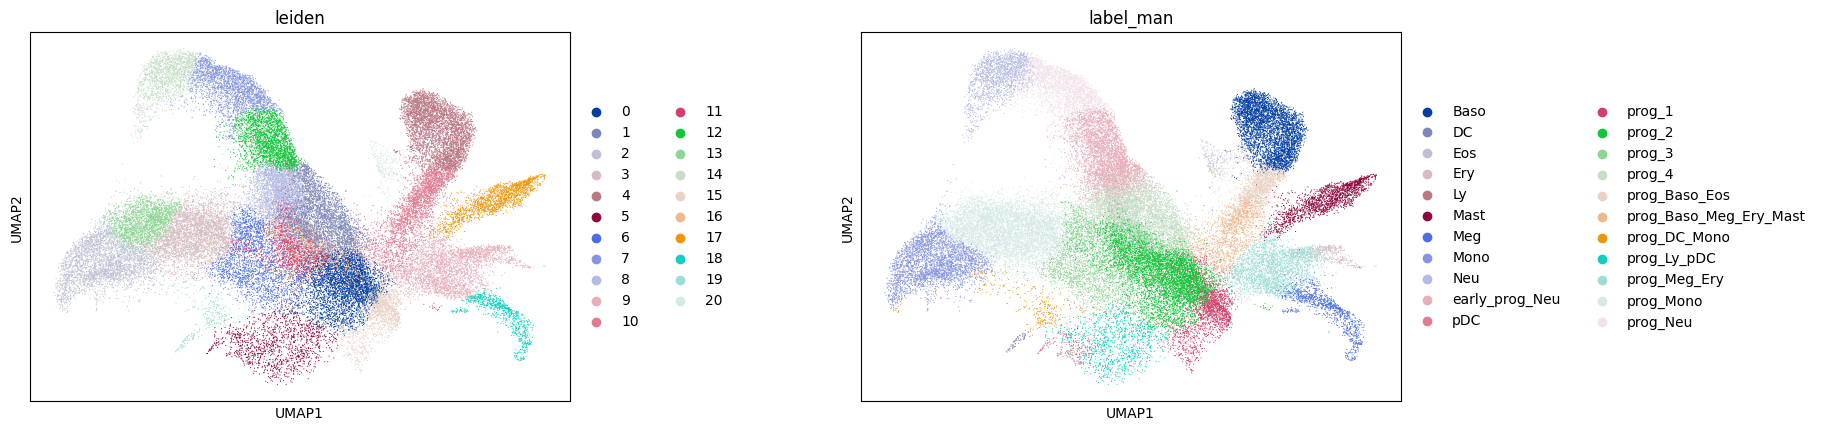

In [10]:
sc.pl.umap(adata, color=['leiden', 'label_man'], wspace=0.4)

In [11]:
selected_cbs = adata.obs.loc[overlapped_cbs].query("`leiden` == '0'").index[:100]
cell_index = [np.where(adata.obs_names == cb)[0].item() for cb in selected_cbs]

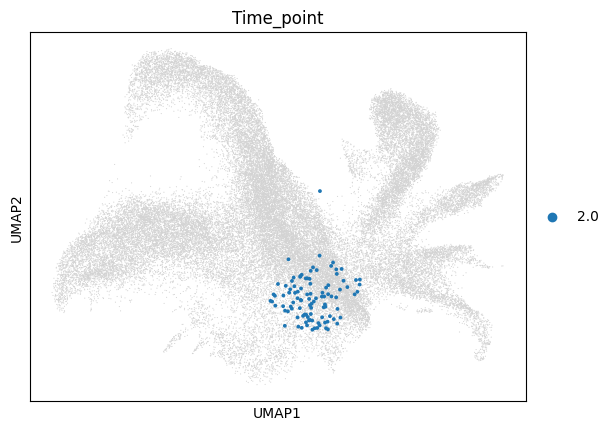

In [12]:
fig = sc.pl.umap(adata, show=False, return_fig=True)
sc.pl.umap(adata[selected_cbs], color='Time_point', s=30, ax=fig.gca())

In [13]:
# cell_index = [np.where(adata.obs_names == cb)[0].item() for cb in overlapped_cbs]

# fig = sc.pl.umap(adata, show=False, return_fig=True)
# sc.pl.umap(adata[overlapped_cbs], color='Time_point', s=30, ax=fig.gca())

In [14]:
from torch import nn

In [15]:
def velocity(t, s):
    t_in = torch.full((s.shape[0],1), t.item()).to(device)
    ds = pde_model.v(s, t_in*pde_model.time_scale_factor)
    return ds

In [16]:
from tqdm.auto import tqdm

In [17]:
# setup ode
# transfer_ode = Density_Transfer_ODE(pde_model)

# initial cell
n_interval = 50
s0 = torch.from_numpy(Dataset.cellstate[cell_index]).float().to(device)
u0 = Dataset.u_b[0, cell_index].float().to(device)
zeros = torch.zeros_like(u0)
duds_init = torch.zeros_like(s0)
integrate_time = np.linspace(1,2,n_interval+1)


with torch.no_grad():
    s_out = odeint(velocity, y0=s0, 
                t=torch.tensor(integrate_time).to(device)*pde_model.time_scale_factor)

    s_traj_ay = s_out.detach().cpu().clone().numpy()


intout  = odeint(
                pde_model,
                y0 = (u0, s0, duds_init, zeros, zeros, zeros),
                t = torch.tensor(integrate_time).type(torch.float32).to(device),
                atol=pde_model.ode_tol,
                rtol=pde_model.ode_tol,
                method='dopri5',
            )
u_traj_ay = nn.functional.relu(intout[0]).detach().cpu().clone().numpy()
del intout, s_out

In [18]:
import torch.nn.functional as F

In [19]:
pde_model = pde_model.to('cpu')

In [20]:
next(pde_model.parameters()).device

device(type='cpu')

In [21]:
model2 = pde_model.to(device)

In [22]:
next(model2.parameters()).device

device(type='cuda', index=5)

In [27]:
ncell = u0.shape[0]

In [33]:
leftover_u_global = [ np.zeros((n_interval, u0.shape[0])) ]
diff_flow_u_global = []

with torch.set_grad_enabled(True):
    for offset in tqdm(range(n_interval)):


        s_traj = torch.from_numpy(s_traj_ay).float().to(device)
        
        tn1 = integrate_time[0]
        diff_flow_u_local = [u_traj_ay[offset]]
        leftover_u_local = []

        pde_model = model_class.load_from_checkpoint(ckpt_path).eval().to(device)

        for i, t in enumerate(integrate_time[1:n_interval-offset+1]):
            
            # if i==0:
            #     t0 = torch.full((s_tn1[0].shape,1), tn1).requires_grad_().to(device).float()
            #     u0 = pde_model.get_u(s_tn1, t0)
            #     diff_flow_u.append(u0.detach())

            s_tn1 = s_traj[i].requires_grad_().to(device)
            s_t = s_traj[i+1].requires_grad_().to(device)
            
            left_u = torch.from_numpy(leftover_u_global[-1][i]).requires_grad_().to(device) # left from last round of diff trajactory
            inflow_u = torch.from_numpy(diff_flow_u_local[-1]).requires_grad_().to(device)  # inflow from last step of the same round of diff trajectory
            u_tn1 = left_u.float() + inflow_u.float()
            u_t = torch.zeros_like(u_tn1).to(device)

            # integrate the flow within small timespan
            s_last, u_stay, s_next, u_flow = odeint(pde_model.density_transfer, 
                            y0= (s_tn1, u_tn1, s_t, u_t), 
                            t = torch.tensor([tn1, t]).float().to(device),
                            rtol = pde_model.ode_tol,
                            atol = pde_model.ode_tol,
                            )
            
            diff_flow_u_local.append( F.relu(u_flow[-1].detach()).clone().cpu().numpy() )
            leftover_u_local.append( F.relu(u_stay[-1].detach()).clone().cpu().numpy() )
            tn1 = t

            del s_tn1, s_t, u_tn1, u_t, left_u, inflow_u, s_last, u_stay, s_next, u_flow
            torch.cuda.empty_cache()
            pde_model.zero_grad()

        diff_flow_u_local = np.stack(diff_flow_u_local)[1:] # length : 100 - offset
        leftover_u_local = np.stack(leftover_u_local)[1:]   # length : 100 - offset - 1

        diff_flow_u_global.append(diff_flow_u_local)
        leftover_u_global.append(leftover_u_local)

        torch.cuda.empty_cache()

        del diff_flow_u_local, leftover_u_local,  s_traj, pde_model
    
        print(torch.cuda.memory_allocated() / 1024**3)
        print(torch.cuda.memory_reserved() / 1024**3)

  0%|          | 0/50 [00:00<?, ?it/s]

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [34]:
Tmap_manual = []
for icell in range(ncell):
    T_M = np.zeros((n_interval,n_interval))
    
    for i,flow_u_t in enumerate(diff_flow_u_global):
        nt = flow_u_t.shape[0]
        
        for j, u in enumerate(flow_u_t[:,icell]):
            T_M[i+j, j] = u

    # plt.matshow(T_M)
    Tmap_manual.append(T_M)

In [35]:
Tmap = np.stack(Tmap_manual)

In [36]:
Tmap.shape

(100, 50, 50)

In [37]:
print(diff_flow_u_global[0].shape)
print(diff_flow_u_global[1].shape)

(50, 100)
(49, 100)


In [38]:
diff_flow_u_global[0][0]

array([8.8032684e-06, 2.0111534e-05, 2.0547513e-05, 1.8982559e-05,
       1.9049616e-05, 1.6441909e-05, 2.1290718e-05, 9.7250868e-06,
       2.0395262e-05, 2.1330930e-05, 2.1377442e-05, 2.2042521e-05,
       1.8739300e-05, 2.1609387e-05, 1.9444715e-05, 2.0371102e-05,
       2.1862717e-05, 1.5201513e-05, 1.9445932e-05, 1.8549843e-05,
       2.2099461e-05, 2.2312512e-05, 3.4097523e-06, 2.0793794e-05,
       1.9071902e-05, 1.9898871e-05, 1.9983660e-05, 2.1009097e-05,
       2.0189547e-05, 2.1217698e-05, 2.1844424e-05, 2.0980995e-05,
       1.7160384e-05, 2.0082825e-05, 2.1593512e-05, 2.0154264e-05,
       2.1044078e-05, 1.8514722e-05, 1.9837262e-05, 1.9599833e-05,
       2.0412668e-05, 1.7933080e-05, 1.9875331e-05, 1.9433373e-05,
       1.7066124e-05, 2.0478517e-05, 1.8852421e-05, 2.1159933e-05,
       1.9205416e-05, 2.0867868e-05, 2.1345615e-05, 1.8745983e-05,
       2.1339374e-05, 2.1320937e-05, 2.1688327e-05, 1.5468913e-05,
       1.9339735e-05, 2.1001229e-05, 2.0593941e-05, 2.1705893e

In [39]:
np.stack([diff_flow_u_global[i][0] for i in range(100)])

IndexError: list index out of range

In [ ]:
np.stack([diff_flow_u_global[i][0] for i in range(100)]).sum(axis=0)

array([9.7321878e-05, 1.0051067e-03, 9.5900387e-04, 8.5012789e-04,
       7.9921150e-04, 3.6236033e-04, 1.2328309e-03, 1.2718211e-04,
       9.1011688e-04, 1.1218261e-03, 1.1639594e-03, 1.2240947e-03,
       9.1097422e-04, 1.2376411e-03, 1.0883461e-03, 1.1754440e-03,
       1.2626920e-03, 8.0526737e-04, 1.0818396e-03, 1.0305869e-03,
       1.2846582e-03, 1.2285922e-03, 2.0067915e-05, 1.1280988e-03,
       1.0271954e-03, 1.1338085e-03, 1.1538612e-03, 1.0169204e-03,
       9.3842606e-04, 1.2022651e-03, 1.1941904e-03, 1.0105971e-03,
       9.2155312e-04, 1.0109625e-03, 1.1207769e-03, 1.1200926e-03,
       1.2000193e-03, 9.6652377e-04, 9.8434149e-04, 1.0381883e-03,
       1.0409727e-03, 9.1494172e-04, 1.1290163e-03, 1.0895333e-03,
       9.2666212e-04, 9.5033686e-04, 1.0597784e-03, 1.2423220e-03,
       1.0963302e-03, 1.2149727e-03], dtype=float32)

In [40]:
diff_flow_u_global[0][:10, :10]

array([[8.80326843e-06, 2.01115345e-05, 2.05475135e-05, 1.89825587e-05,
        1.90496157e-05, 1.64419089e-05, 2.12907180e-05, 9.72508678e-06,
        2.03952623e-05, 2.13309304e-05],
       [1.79858637e-06, 3.35317009e-06, 4.03454533e-06, 4.65285575e-06,
        3.89656816e-06, 3.83928682e-06, 3.43836973e-06, 1.99172632e-06,
        3.98091697e-06, 3.73799753e-06],
       [1.40925533e-06, 1.67377630e-06, 2.85021656e-06, 4.26764473e-06,
        3.00258171e-06, 3.72300519e-06, 1.60889078e-06, 1.58825276e-06,
        2.76979836e-06, 2.09763812e-06],
       [2.02908132e-06, 1.27971430e-06, 3.29055933e-06, 7.29476733e-06,
        3.88740682e-06, 6.09177505e-06, 1.16516708e-06, 2.32290176e-06,
        3.10852442e-06, 1.84671239e-06],
       [2.20652055e-06, 7.50817435e-07, 2.77280742e-06, 1.04444471e-05,
        3.67727057e-06, 7.20491835e-06, 6.55825772e-07, 2.55502437e-06,
        2.53750591e-06, 1.21463029e-06],
       [1.70895510e-06, 3.71771335e-07, 1.74444824e-06, 1.07412325e-05,
   

In [43]:
transport_overtime = Tmap.sum(axis=1)
transport_overtime = transport_overtime / transport_overtime.sum(axis=1, keepdims=True)

In [44]:
transport_overtime

array([[1.63952347e-01, 3.55947278e-02, 2.27374975e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.50628937e-01, 1.14004389e-01, 7.08636548e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.67342538e-01, 3.95239176e-02, 2.92829533e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.69251337e-01, 6.19573959e-02, 4.50581573e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.22343089e-01, 1.22873052e-01, 6.79830684e-02, ...,
        2.84271193e-23, 0.00000000e+00, 0.00000000e+00],
       [5.72158361e-01, 1.16859063e-01, 6.99496073e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

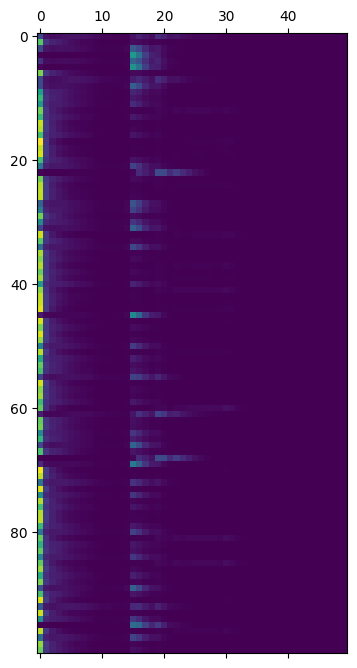

In [45]:
plt.matshow(transport_overtime)

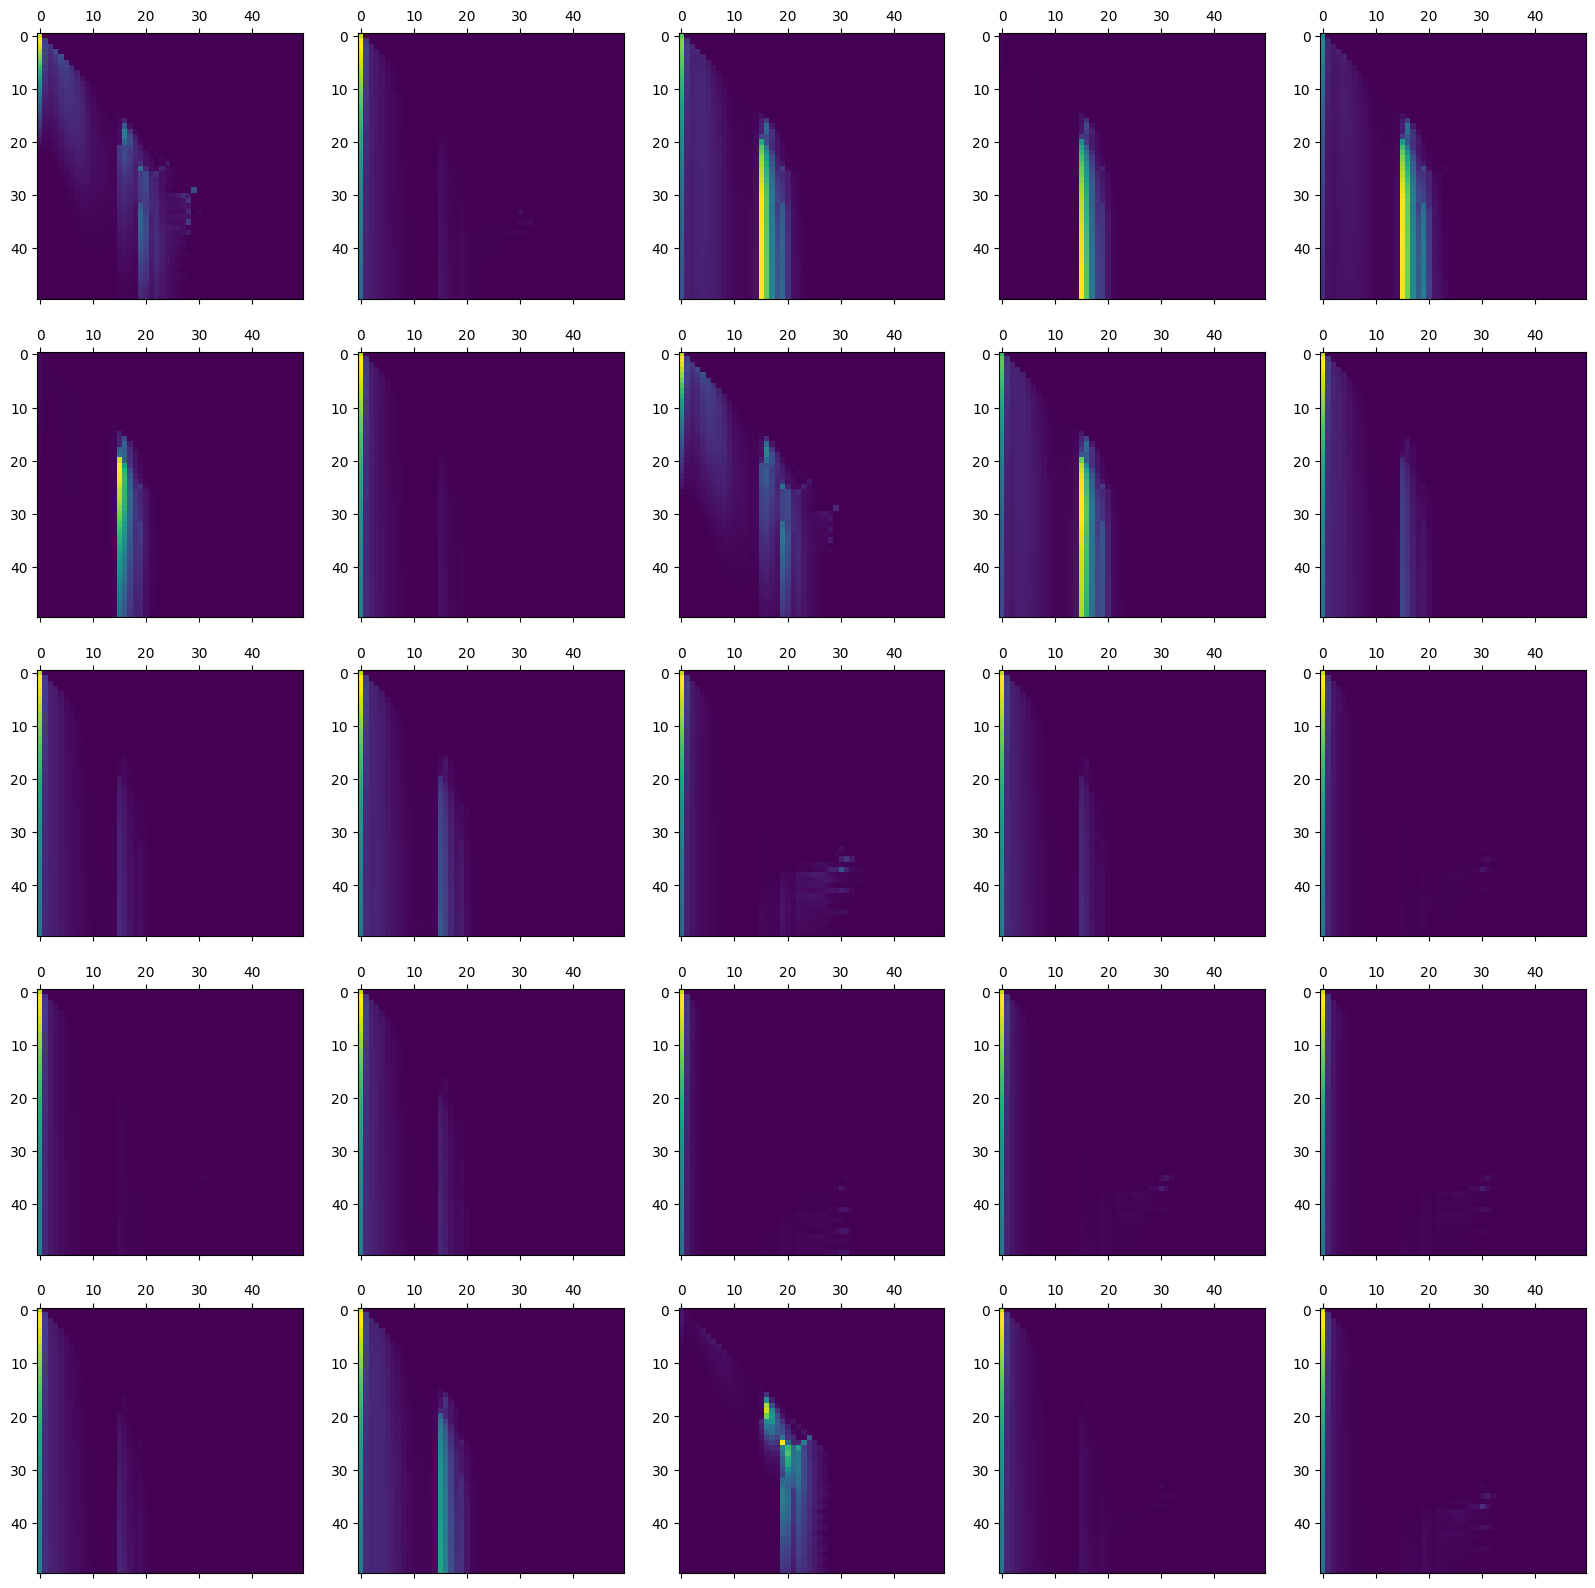

In [46]:
fig, axs = plt.subplots(5,5, figsize=(20,20))
axs = axs.flatten()

for i in range(25):
    axs[i].matshow(Tmap[i])

In [30]:
np.where(transport_maps[0][:50].sum(axis=0) <= 0)[0].min()

49

In [31]:
np.where(transport_maps[0].sum(axis=0) <= 0)[0].min()

50